### 提示词

读取cleandata_example.csv文件，做上升公司数量年度趋势分析，包含每年的上市公司总数、深圳交易所上市公司数量（主板上市公司数量、中小板上市公司数量、创业板上市公司数量）、上海交易所上市公司数量（主板上市公司数量、科创板上市公司数量）北交所上市公司数量，在一个表格和一张堆叠图呈现，不用输出csv和png。再分析最新年度整体上市公司行业分布、深圳交易所上市公司行业分布、上海交易所上市公司行业分布、北交所上市公司行业分布，用表格和饼图呈现，不用输出csv和png

=== 上市公司数量年度趋势分析 ===
      上市公司总数  深交所总数  深交所-主板  深交所-中小板  深交所-创业板  上交所总数  上交所-主板  上交所-科创板  北交所总数
上市年份                                                                        
2005       1      0       0        0        0      0       0        0      1
2008       2      1       1        0        0      1       0        1      0
2025       5      2       1        1        0      2       0        2      1


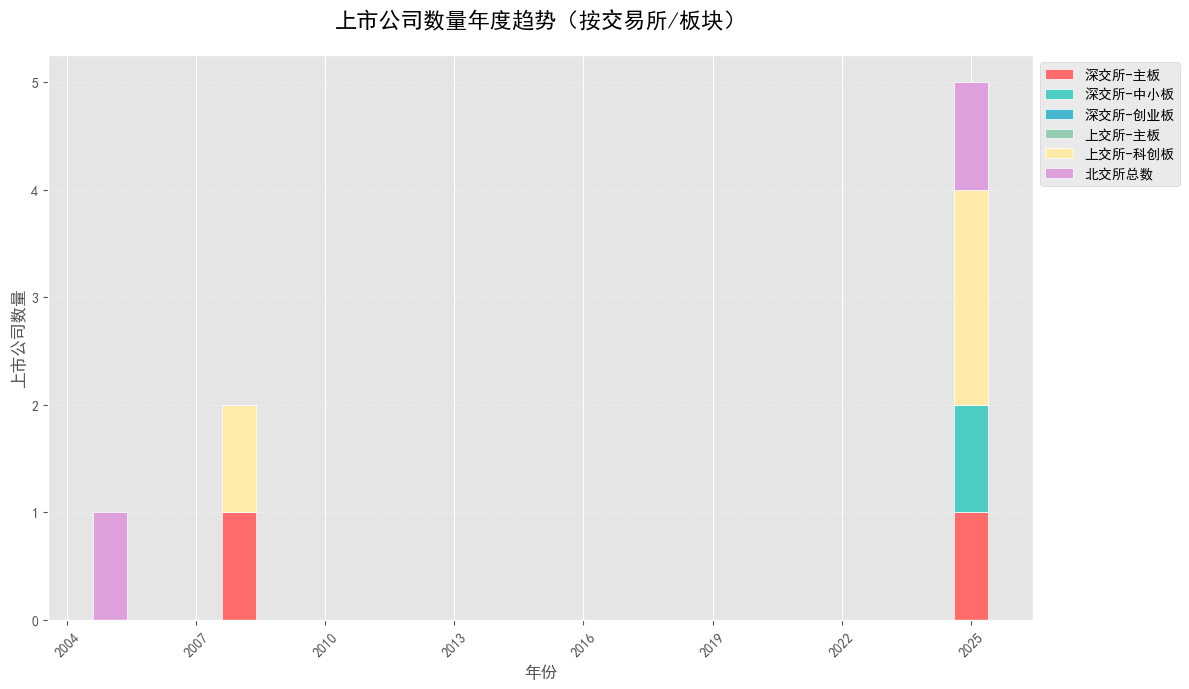

\n=== 最新年度（2025年）行业分布分析 ===
\n1. 整体上市公司行业分布：
                  公司数量
行业                    
汽车制造业                3
计算机、通信和其他电子设备制造业     1
通用设备制造业              1
\n2. 深交所上市公司行业分布：
         公司数量
行业           
汽车制造业       1
通用设备制造业     1
\n3. 上交所上市公司行业分布：
                  公司数量
行业                    
汽车制造业                1
计算机、通信和其他电子设备制造业     1
\n4. 北交所上市公司行业分布：
       公司数量
行业         
汽车制造业     1


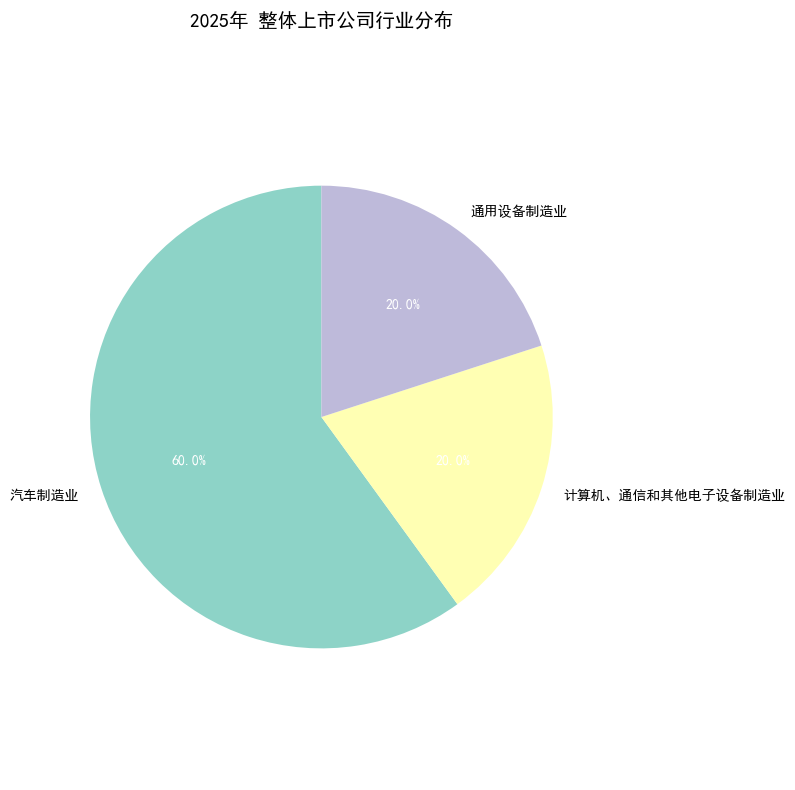

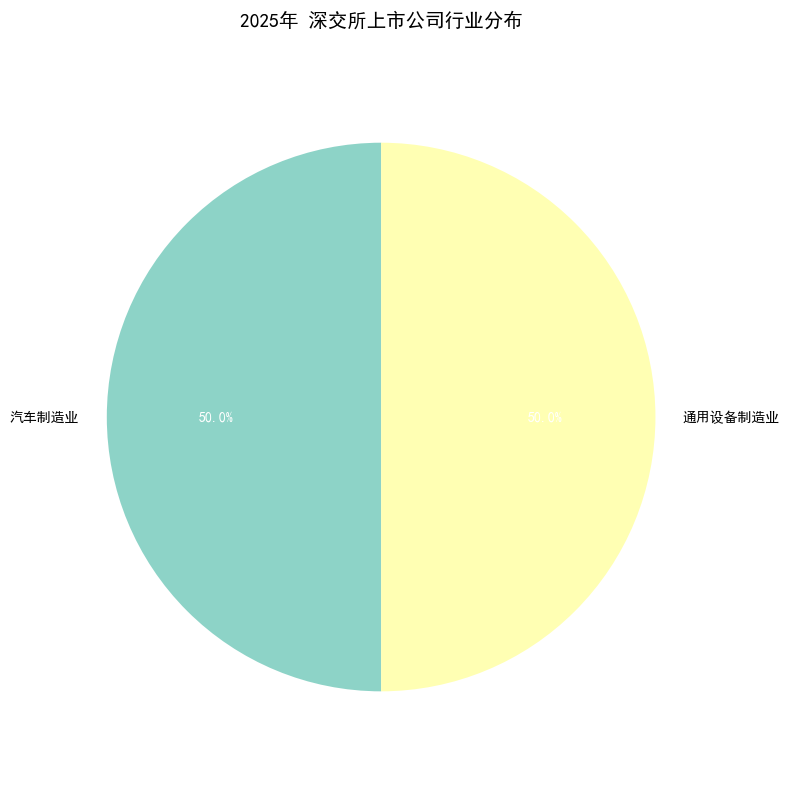

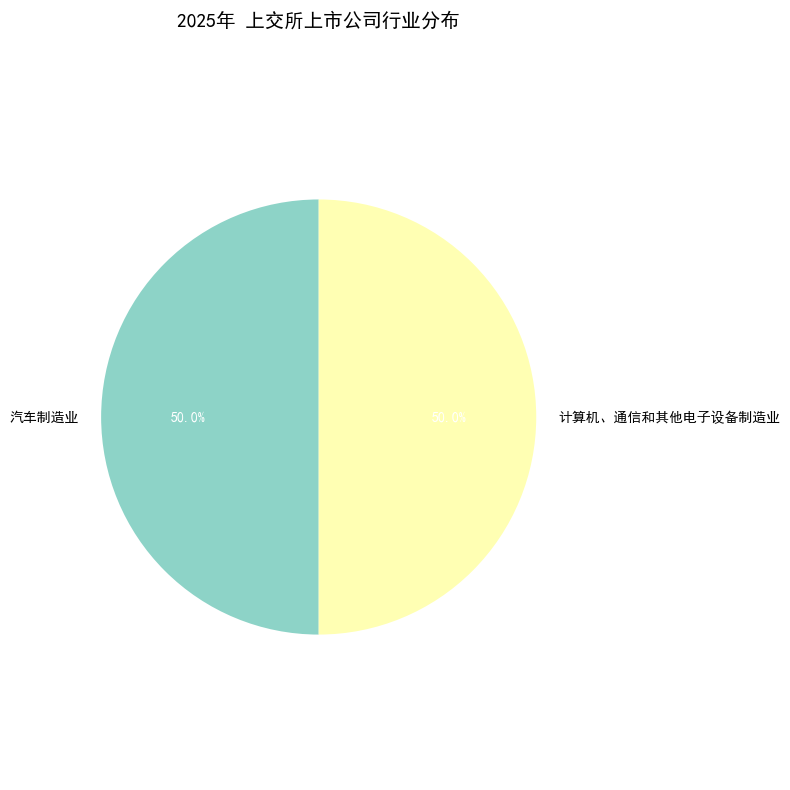

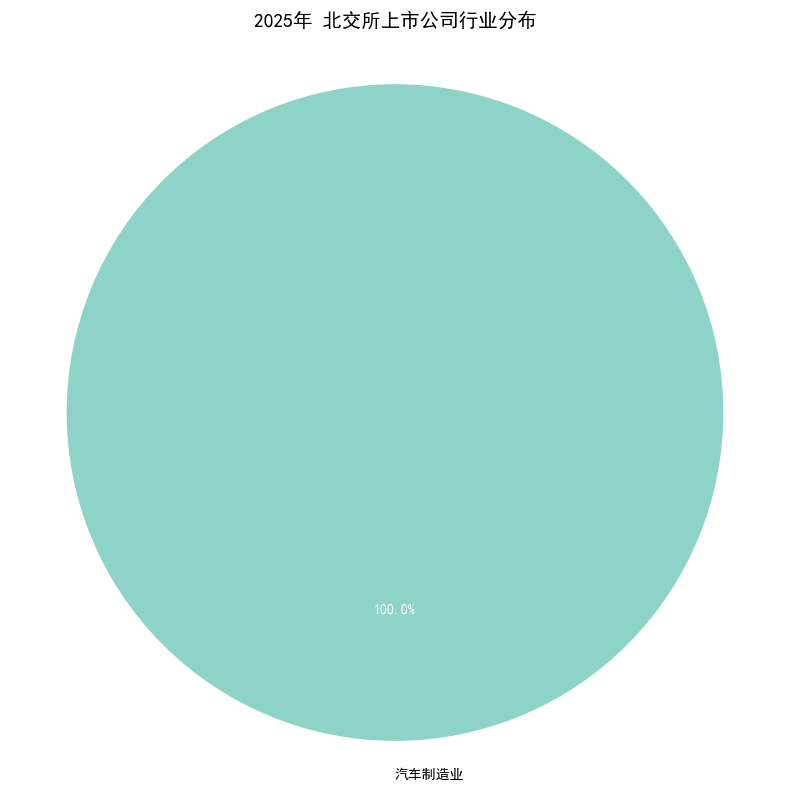

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ==================== 全局配置（解决中文显示问题） ====================
plt.rcParams['font.family'] = ['DejaVu Sans']  # 重置默认字体
plt.rcParams['axes.unicode_minus'] = False     # 解决负号显示问题

# 自动适配系统中文字体
try:
    plt.rcParams['font.family'] = ['SimHei']      # Windows黑体
except:
    try:
        plt.rcParams['font.family'] = ['PingFang SC']  # Mac苹方
    except:
        try:
            plt.rcParams['font.family'] = ['WenQuanYi Zen Hei']  # Linux文泉驿
        except:
            pass

# ==================== 数据读取与预处理 ====================
def load_and_preprocess_data(file_path):
    """读取数据并统一格式"""
    df = pd.read_csv(file_path)
    
    # 统一核心字段名
    df.rename(columns={
        '上市日期': '上市日期',
        '交易所': '交易所',
        '板块': '板块',
        '行业': '行业'  # 确保行业字段名统一
    }, inplace=True)
    
    # 处理日期和年份
    df['上市日期'] = pd.to_datetime(df['上市日期'], errors='coerce')
    df['上市年份'] = df['上市日期'].dt.year.dropna().astype(int)
    
    # 统一交易所/板块命名（解决数据不规范）
    exchange_mapping = {
        '深圳证券交易所': '深交所',
        '深圳交易所': '深交所',
        '上海证券交易所': '上交所',
        '上海交易所': '上交所',
        '北京证券交易所': '北交所',
        '北交所': '北交所'
    }
    board_mapping = {'主板':'主板', '中小板':'中小板', '创业板':'创业板', '科创板':'科创板'}
    df['交易所'] = df['交易所'].map(exchange_mapping).fillna(df['交易所'])
    df['板块'] = df['板块'].map(board_mapping).fillna(df['板块'])
    
    return df

# ==================== 第一部分：年度数量趋势分析 ====================
def calculate_yearly_stats(df):
    """计算每年各交易所/板块的上市公司数量"""
    # 按年份+交易所统计总数
    yearly_exchange = df.groupby(['上市年份', '交易所']).size().unstack(fill_value=0)
    for exchange in ['深交所', '上交所', '北交所']:
        if exchange not in yearly_exchange.columns:
            yearly_exchange[exchange] = 0
    
    # 深交所各板块统计
    sz_board = df[df['交易所']=='深交所'].groupby(['上市年份', '板块']).size().unstack(fill_value=0)
    for board in ['主板', '中小板', '创业板']:
        sz_board[board] = sz_board.get(board, 0)
    sz_board = sz_board[['主板', '中小板', '创业板']]
    
    # 上交所各板块统计
    sh_board = df[df['交易所']=='上交所'].groupby(['上市年份', '板块']).size().unstack(fill_value=0)
    for board in ['主板', '科创板']:
        sh_board[board] = sh_board.get(board, 0)
    sh_board = sh_board[['主板', '科创板']]
    
    # 合并成最终统计表格
    stats_df = pd.DataFrame(index=yearly_exchange.index.sort_values())
    stats_df['上市公司总数'] = yearly_exchange.sum(axis=1)
    # 深交所
    stats_df['深交所总数'] = yearly_exchange['深交所']
    stats_df['深交所-主板'] = sz_board['主板'].reindex(stats_df.index, fill_value=0)
    stats_df['深交所-中小板'] = sz_board['中小板'].reindex(stats_df.index, fill_value=0)
    stats_df['深交所-创业板'] = sz_board['创业板'].reindex(stats_df.index, fill_value=0)
    # 上交所
    stats_df['上交所总数'] = yearly_exchange['上交所']
    stats_df['上交所-主板'] = sh_board['主板'].reindex(stats_df.index, fill_value=0)
    stats_df['上交所-科创板'] = sh_board['科创板'].reindex(stats_df.index, fill_value=0)
    # 北交所
    stats_df['北交所总数'] = yearly_exchange['北交所']
    
    return stats_df

def plot_yearly_stacked_bar(stats_df):
    """绘制年度趋势堆叠图"""
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # 定义颜色
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']
    cols = ['深交所-主板', '深交所-中小板', '深交所-创业板', 
            '上交所-主板', '上交所-科创板', '北交所总数']
    
    # 堆叠绘制
    bottom = pd.Series([0]*len(stats_df), index=stats_df.index)
    for i, col in enumerate(cols):
        ax.bar(stats_df.index, stats_df[col], bottom=bottom, 
               label=col, color=colors[i], edgecolor='white', linewidth=0.5)
        bottom += stats_df[col]
    
    # 图表美化
    ax.set_title('上市公司数量年度趋势（按交易所/板块）', fontsize=16, pad=20)
    ax.set_xlabel('年份', fontsize=12)
    ax.set_ylabel('上市公司数量', fontsize=12)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# ==================== 第二部分：最新年度行业分布分析 ====================
def calculate_latest_industry_dist(df):
    """计算最新年度的行业分布（整体+各交易所）"""
    # 获取最新年份
    latest_year = df['上市年份'].max()
    print(f"\\n=== 最新年度（{latest_year}年）行业分布分析 ===")
    
    # 筛选最新年度数据
    latest_df = df[df['上市年份'] == latest_year].copy()
    
    # 1. 整体行业分布
    total_industry = latest_df.groupby('行业').size().sort_values(ascending=False)
    # 2. 深交所行业分布
    sz_industry = latest_df[latest_df['交易所']=='深交所'].groupby('行业').size().sort_values(ascending=False)
    # 3. 上交所行业分布
    sh_industry = latest_df[latest_df['交易所']=='上交所'].groupby('行业').size().sort_values(ascending=False)
    # 4. 北交所行业分布
    bj_industry = latest_df[latest_df['交易所']=='北交所'].groupby('行业').size().sort_values(ascending=False)
    
    return {
        'latest_year': latest_year,
        'total': total_industry,
        'sz': sz_industry,
        'sh': sh_industry,
        'bj': bj_industry
    }

def plot_industry_pie(industry_data, title):
    """绘制行业分布饼图（处理数据过多的情况）"""
    # 若行业数>10，合并尾部为"其他"
    if len(industry_data) > 10:
        top_9 = industry_data.head(9)
        other = pd.Series([industry_data.tail(-9).sum()], index=['其他'])
        industry_data = pd.concat([top_9, other])
    
    # 绘制饼图
    fig, ax = plt.subplots(figsize=(8, 8))
    wedges, texts, autotexts = ax.pie(
        industry_data.values,
        labels=industry_data.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=plt.cm.Set3.colors,
        textprops={'fontsize': 10}
    )
    
    # 美化百分比文字
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    
    ax.set_title(title, fontsize=14, pad=20)
    ax.axis('equal')  # 保证饼图为正圆
    plt.tight_layout()
    plt.show()

def print_industry_tables(industry_dist):
    """打印各维度行业分布表格"""
    latest_year = industry_dist['latest_year']
    
    # 1. 整体行业分布
    print("\\n1. 整体上市公司行业分布：")
    print(industry_dist['total'].to_frame('公司数量'))
    
    # 2. 深交所行业分布
    print("\\n2. 深交所上市公司行业分布：")
    if not industry_dist['sz'].empty:
        print(industry_dist['sz'].to_frame('公司数量'))
    else:
        print("无数据")
    
    # 3. 上交所行业分布
    print("\\n3. 上交所上市公司行业分布：")
    if not industry_dist['sh'].empty:
        print(industry_dist['sh'].to_frame('公司数量'))
    else:
        print("无数据")
    
    # 4. 北交所行业分布
    print("\\n4. 北交所上市公司行业分布：")
    if not industry_dist['bj'].empty:
        print(industry_dist['bj'].to_frame('公司数量'))
    else:
        print("无数据")

def show_industry_dist_plots(industry_dist):
    """展示各维度行业分布饼图"""
    latest_year = industry_dist['latest_year']
    
    # 1. 整体行业分布饼图
    if not industry_dist['total'].empty:
        plot_industry_pie(industry_dist['total'], f'{latest_year}年 整体上市公司行业分布')
    else:
        print(f"\\n{latest_year}年无整体行业数据")
    
    # 2. 深交所行业分布饼图
    if not industry_dist['sz'].empty:
        plot_industry_pie(industry_dist['sz'], f'{latest_year}年 深交所上市公司行业分布')
    else:
        print(f"\\n{latest_year}年深交所无行业数据")
    
    # 3. 上交所行业分布饼图
    if not industry_dist['sh'].empty:
        plot_industry_pie(industry_dist['sh'], f'{latest_year}年 上交所上市公司行业分布')
    else:
        print(f"\\n{latest_year}年上交所无行业数据")
    
    # 4. 北交所行业分布饼图
    if not industry_dist['bj'].empty:
        plot_industry_pie(industry_dist['bj'], f'{latest_year}年 北交所上市公司行业分布')
    else:
        print(f"\\n{latest_year}年北交所无行业数据")

# ==================== 主执行流程 ====================
if __name__ == '__main__':
    # 1. 读取数据（替换为你的文件路径）
    file_path = 'data_clean\cleandata_example.csv'
    df = load_and_preprocess_data(file_path)
    
    # ==================== 第一部分：年度趋势分析 ====================
    print("=== 上市公司数量年度趋势分析 ===")
    yearly_stats = calculate_yearly_stats(df)
    print(yearly_stats.round(0))  # 控制台打印表格
    plot_yearly_stacked_bar(yearly_stats)  # 显示堆叠图
    
    # ==================== 第二部分：最新年度行业分布分析 ====================
    industry_dist = calculate_latest_industry_dist(df)
    print_industry_tables(industry_dist)  # 控制台打印行业表格
    show_industry_dist_plots(industry_dist)  # 显示各维度饼图